**DO NOT DOWNLOAD THIS NOTEBOOK.**

The package requirements are rather specific because of updates to numpy and scipy which broke `fastsparsegams`.

Please do not come to the TA team with package issues on your local machine.

Useful links:

[FastSparseGams PyPI page](https://pypi.org/project/fastsparsegams/)


[Scikit Learn Random Forest Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

[Scikit Learn AdaBoost Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)


[XGBoost Documentation](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)

[InterpretML ExplainableBoostingClassifier Documentation](https://interpret.ml/docs/python/api/ExplainableBoostingClassifier.html)

[GAMChanger](https://interpret.ml/gam-changer/)


# Homework 2, Problem 3

## GAMs and the Rashomon Effect

### Setup (all provided, do not modify)

#### Package dependencies and imports

In [1]:
# ensures that fastsparsegams can run
# fastsparsegams has been marred by the
# sinister appetite of software deprecation
!pip install 'numpy<2.0'
# This will throw an error but it will still work. Don't be scared of the red.
!pip install 'scipy<1.13.0'
!pip install fastsparsegams

!pip install ucimlrepo
!pip install interpret gamchanger

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

import gamchanger as gc
from interpret.glassbox import ExplainableBoostingClassifier

import fastsparsegams as fsg

/Users/yd211/Documents/GitHub/CS_671/.conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Helper Functions You **Won't** Need To Use Yourself

In [3]:
# This code is pulled straight from the l0learn/fastsparsegams package.
# We'll use this to setup our binary data for fastsparsegams.
def convert_continuous_df_to_binary_df(df): 
    """Convert continuous features to binary features in the dataframe.

    Generates 100 percentile thresholds for each feature.

    Parameters:
        df (pandas.DataFrame): The input dataframe containing continuous features.

    Returns:
        pandas.DataFrame: The binary dataframe with converted features.
    """
    colnames = df.columns
    n = len(df)
    print("Make sure your first column corresponds to the y label")
    print("Converting continuous features to binary features in the dataframe......")

    percentile_ticks = range(1, 101)

    binarized_dict = {}

    for i in range(0, len(colnames)):
        uni = df[colnames[i]].unique()
        if len(uni) == 2:
            binarized_dict[colnames[i]] = np.asarray(df[colnames[i]], dtype=int)
            continue

        uni.sort()
        if len(uni) >= 100:
            uni = np.percentile(uni, percentile_ticks)
        for j in range(len(uni) - 1):
            tmp_feature = np.ones(n, dtype=int)
            tmp_name = colnames[i] + "<=" + str(uni[j])

            zero_indices = df[colnames[i]] > uni[j]
            tmp_feature[zero_indices] = 0

            binarized_dict[tmp_name] = tmp_feature

    binarized_df = pd.DataFrame(binarized_dict)
    print("Finish converting continuous features to binary features......")
    return binarized_df

In [4]:
# THIS CELL CONTAINS HELPER FUNCTIONS FOR THE TWO PROVIDED PLOTTING UTILITIES.
# YOU DON'T NEED TO DIRECTLY USE ANY OF THESE.

def get_xgb_tree_coeffs(xgb_model):
    """Get the coefficients of the decision tree splits in an XGBoost model.

    Parameters:
        xgb_model: The trained XGBoost model.

    Returns:
        pandas.DataFrame: The coefficients of the decision tree splits.
    """
    booster = xgb_model.get_booster()
    # get the features that are used in the xgboost model and their splits
    tree_df = booster.trees_to_dataframe()

    better_tree_df = tree_df[tree_df['Feature'] != 'Leaf'].copy()
    better_tree_df.loc[:, '< coeff'] = tree_df.loc[tree_df['Node'] == 1, 'Gain'].to_numpy()
    better_tree_df.loc[:, '> coeff'] = tree_df.loc[tree_df['Node'] == 2, 'Gain'].to_numpy()
    return better_tree_df[["Feature", "Split", "< coeff", "> coeff"]]


def extract_stump_info(stump: tree.DecisionTreeClassifier):
    """Get the feature, threshold value, and the predictions at each leaf node
    for a decision stump implemented in scikit-learn's DecisionTreeClassifier format.

    Parameters:
        stump (tree.DecisionTreeClassifier): The decision stump.

    Returns:
        tuple: A tuple containing the feature, threshold value,
            and the predictions at each leaf node.
    """
    feature = stump.tree_.feature[0]
    threshold = stump.tree_.threshold[0]

    leq_values = stump.tree_.value[1][0]
    gt_values = stump.tree_.value[2][0]

    return feature, threshold, leq_values, gt_values


def get_sklearn_adaboost_coeffs(adaboost, columns):
    """Get the coefficients of the decision tree splits in an AdaBoost model.

    Parameters:
        adaboost: The trained AdaBoost model.
        columns: The column names of the input data.

    Returns:
        pandas.DataFrame: The coefficients of the decision tree splits.
    """

    features, thresholds, leq_preds, gt_preds = [], [], [], []
    weights = adaboost.estimator_weights_
    for i, dtree in enumerate(adaboost.estimators_):
        feature, threshold, leq_values, gt_values = extract_stump_info(dtree)
        features.append(columns[feature])
        thresholds.append(threshold)
        leq_preds.append(np.argmax(leq_values) * weights[i])
        gt_preds.append(np.argmax(gt_values) * weights[i])
    adaboost_coeffs = pd.DataFrame({
        "Feature": features,
        "Split": thresholds,
        "< coeff": leq_preds,
        "> coeff": gt_preds
    })
    return adaboost_coeffs


def get_sklearn_rf_coeffs(rf, columns):
    """Get the coefficients of the decision tree splits in a tree-based sklearn ensemble.

    Parameters:
        rf: The trained random forest model.
        columns: The column names of the input data.

    Returns:
        pandas.DataFrame: The coefficients of the decision tree splits.
    """
    features, thresholds, leq_preds, gt_preds = [], [], [], []
    for dtree in rf.estimators_:
        feature, threshold, leq_values, gt_values = extract_stump_info(dtree)
        features.append(columns[feature])
        thresholds.append(threshold)
        leq_preds.append(leq_values[1] / (leq_values[0] + leq_values[1]))
        gt_preds.append(gt_values[1] / (gt_values[0] + gt_values[1]))
    rf_coeffs = pd.DataFrame({"Feature": features, "Split": thresholds, "< coeff": leq_preds, "> coeff": gt_preds})
    return rf_coeffs


def convert_coefficients_to_shape_function(coefficients, direction="<"):
    """Convert the gam feature coefficients to a step/shape function.

    This is needed to make the coefficient representation conform to the
    alignment expectations of plt.step, which are somewhat unintuitive.
    You can figure out how to do this yourself with a whiteboard and some patience,
    but I did that for you :)

    Parameters:
        coefficients (list[float]): The coefficients of the shape function.
        direction (str, optional): The direction of the step function.
            Can be "<" or ">". Defaults to "<".

    Returns:
        list[float]: The step function coefficients.
    """
    coefficients_steps = np.zeros(len(coefficients)+2)
    if direction == "<":
        coeff_reverse_cumsum = np.cumsum(coefficients[::-1])[::-1]
        coefficients_steps[1:-1] = coeff_reverse_cumsum
        coefficients_steps[0] = coeff_reverse_cumsum[0]
    else:
        coeff_cumsum = np.cumsum(coefficients)
        coefficients_steps[2:] = coeff_cumsum
    return coefficients_steps


def plot_shape_function(steps: list[float], coefficients: list[float], feature_name: str, ax=None):
    """Plot the shape function of the GAM for a single feature.

    The shape function is a piecewise constant function that is the sum of the coefficients
    where the feature value is less than or equal to the step (or greater than).

    Parameters:
        steps (list[float]): The steps in the shape function. Assume these are sorted in ascending order.
        coefficients (list[float]): The coefficients of the shape function.
        feature_name (str): The name of the feature.
        ax (matplotlib.axes.Axes, optional): The axes on which to plot the shape function.
            If not provided, a new figure and axes will be created.

    Returns:
        None
    """
    if ax is None:
        fig, ax = plt.subplots()
    ax.step(steps, coefficients, where="pre")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Shape function")
    ax.set_title(f"Shape function for {feature_name}")

#### Helper Functions You **Will** Need To Use Yourself

In [5]:
def plot_shape_functions_fastsparse(gam, binary_cols, continuous_df, lambda_0=0):
    """Plot the shape functions of a GAM model using the fastsparse package.

    Parameters:
        gam: The trained GAM model.
        binary_cols: The binary column names used in the GAM model.
        continuous_df: The continuous dataframe used in the GAM model.
        lambda_0 (float, optional): The regularization parameter. Defaults to 0.

    Returns:
        None
    """
    gam_coeffs = gam.coeff(lambda_0=lambda_0)
    intercept = gam_coeffs[0]
    coefficients = gam_coeffs[1:]
    used_binary_features = binary_cols[coefficients.indices]
    feature_names = np.unique([feature.split("<=")[0] for feature in used_binary_features])
    print(intercept)

    n_features = len(feature_names)
    ncols = min(3, n_features)
    nrows = int(np.ceil(n_features / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for idx, feature_name in enumerate(feature_names):
        feature_indices = [i for i, feature in enumerate(used_binary_features) if feature_name in feature]
        feature_min = continuous_df[feature_name].min()
        feature_max = continuous_df[feature_name].max()
        steps = [float(feature.split("<=")[1]) for feature in used_binary_features[feature_indices]]
        steps = [feature_min] + steps + [feature_max]

        coefficients_lte = gam_coeffs.data[feature_indices]
        coefficients_lte_steps = convert_coefficients_to_shape_function(coefficients_lte, direction="<")
        coefficients = coefficients_lte_steps

        plot_shape_function(steps, coefficients, feature_name, ax=axes[idx])

    # Hide unused axes
    for j in range(len(feature_names), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_shape_functions_tree_ensemble(ensemble, continuous_df):
    """Plot the shape functions of a tree ensemble model.

    Parameters:
        ensemble: The decision tree ensemble.
        continuous_df: The continuous dataframe used in the tree ensemble model.

    Returns:
        None
    """
    if isinstance(ensemble, AdaBoostClassifier):
        ensemble_df = get_sklearn_adaboost_coeffs(ensemble, continuous_df.columns)
    elif isinstance(ensemble, RandomForestClassifier):
        ensemble_df = get_sklearn_rf_coeffs(ensemble, continuous_df.columns)
    elif isinstance(ensemble, XGBClassifier):
        ensemble_df = get_xgb_tree_coeffs(ensemble)
    else:
        raise ValueError("Only AdaBoost, RandomForest, and XGBoost models are supported")

    feature_names = np.unique(ensemble_df['Feature'])
    n_features = len(feature_names)
    ncols = min(3, n_features)
    nrows = int(np.ceil(n_features / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for idx, feature_name in enumerate(feature_names):
        feature_df = ensemble_df[ensemble_df['Feature'] == feature_name].sort_values('Split')
        steps = feature_df['Split'].to_numpy()

        feature_min = continuous_df[feature_name].min()
        feature_max = continuous_df[feature_name].max()
        steps = [feature_min] + list(steps) + [feature_max]

        coefficients_lt = feature_df['< coeff'].to_numpy()
        coefficients_gte = feature_df['> coeff'].to_numpy()
        coefficients_lt_steps = convert_coefficients_to_shape_function(coefficients_lt, direction="<")
        coefficients_gte_steps = convert_coefficients_to_shape_function(coefficients_gte, direction=">")
        coefficients = coefficients_lt_steps + coefficients_gte_steps

        plot_shape_function(steps, coefficients, feature_name, ax=axes[idx])

    # Hide unused axes
    for j in range(len(feature_names), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

#### Setup Data (Please read)

For this homework assignment, we will use a dataset which has various chemical measurements about wine, used to predict wine quality. The task is to predict whether or not the wine will be assigned a quality of "average" (6) or better.

We separate the data out into train/validation/test splits of sizes 75/10/15%, respectively.

In [6]:
# fetch dataset
wine_dataset = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_dataset.data.features
y = wine_dataset.data.targets

y = (y >= 6).astype(int)

# split into 15% test, 10% validation, 75% train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1/(1-.15), random_state=43)

X_train

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
1337,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5
4708,6.9,0.300,0.36,4.5,0.054,31.0,203.0,0.99513,3.40,0.57,10.4
1892,6.2,0.280,0.22,7.3,0.041,26.0,157.0,0.99570,3.44,0.64,9.8
5192,5.6,0.280,0.28,4.2,0.044,52.0,158.0,0.99200,3.35,0.44,10.7
1331,7.8,0.870,0.26,3.8,0.107,31.0,67.0,0.99668,3.26,0.46,9.2
...,...,...,...,...,...,...,...,...,...,...,...
4840,5.8,0.300,0.42,1.1,0.036,19.0,113.0,0.98871,3.10,0.46,12.6
5529,6.1,0.280,0.26,1.5,0.030,25.0,101.0,0.98894,3.03,0.41,12.1
1213,9.6,0.380,0.42,1.9,0.071,5.0,13.0,0.99659,3.15,0.75,10.5
1812,6.7,0.130,0.29,5.3,0.051,31.0,122.0,0.99440,3.44,0.37,9.7


We use a utility provided by the `fastsparsegams` library to binarize the data; this function splits the data into at most 100 percentile bins (fewer if the feature has less than 100 distinct values), where the feature value for a particular row is 1 if and only if it is less than or equal to the split value.
We take care to make sure we're using the same train/val/test splits as in the continuous data.

We do this for use by FastSparseGAMs, which does not internally binarize the data. If we just ran FastSparseGAMs with continuous data, it would give us a linear model over the features. We want to fit a GAM, not a linear model.

In [7]:
binary_df = convert_continuous_df_to_binary_df(pd.concat([y, X], axis=1))
X_binary = binary_df[binary_df.columns[1:]]
y_binary = binary_df[binary_df.columns[0]]

X_binary_train = X_binary.iloc[X_train.index]
y_binary_train = y_binary.iloc[X_train.index]

X_binary_val = X_binary.iloc[X_val.index]
y_binary_val = y_binary.iloc[X_val.index]

X_binary_test = X_binary.iloc[X_test.index]
y_binary_test = y_binary.iloc[X_test.index]

X_binary_train

Make sure your first column corresponds to the y label
Converting continuous features to binary features in the dataframe......
Finish converting continuous features to binary features......


,fixed_acidity<=3.915,fixed_acidity<=4.220000000000001,fixed_acidity<=4.415,fixed_acidity<=4.52,fixed_acidity<=4.625,fixed_acidity<=4.73,fixed_acidity<=4.835,fixed_acidity<=4.94,fixed_acidity<=5.045,fixed_acidity<=5.15,...,alcohol<=13.4,alcohol<=13.505,alcohol<=13.553333334000001,alcohol<=13.576666669,alcohol<=13.639999999999999,alcohol<=13.75,alcohol<=13.86,alcohol<=13.97,alcohol<=14.040000000000001,alcohol<=14.185
1337,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
4708,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1892,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
5192,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1331,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4840,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
5529,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1213,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1812,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1


### (a) Fitting a GAM using FastSparseGAMs on the binary training data.

In [8]:
# 1) Prepare data -- ensure types
X_train_fsg = X_binary_train.values.astype(float)
y_train_fsg = y_binary_train.values
X_val_fsg   = X_binary_val.values.astype(float)
y_val_fsg   = y_binary_val.values

# 2) Fit the model
gam = fsg.fit(X_train_fsg, y_train_fsg, penalty="L0", algorithm="CDPSI", loss="Logistic", max_support_size=25)

# 3) Extract solution path
char = pd.DataFrame(gam.characteristics())
lambdas = np.asarray(char["l0"], dtype=float)
supports = np.asarray(char["support_size"], dtype=int)

# 4) Evaluate validation accuracy for each λ₀
val_accs = []
for lam, supp in zip(lambdas, supports):
    y_pred_val = gam.predict(X_val_fsg, lambda_0=lam)
    y_pred_val = (y_pred_val >= 0.5).astype(int)
    acc = accuracy_score(y_val_fsg, y_pred_val)
    val_accs.append((lam, acc, supp))

# 5) Select best λ₀ (max accuracy → tie-break by smaller support → smaller λ)
## IMPORTANT -- we add a tiebreak here to ensure that we select the smallest lambda
val_accs_sorted = sorted(val_accs, key=lambda t: (-t[1], t[2], t[0]))
best_lambda_0, best_val_acc, best_support = val_accs_sorted[0]

# 6) Print results
print("\n[FastSparseGAMs] Best on validation")
print(f"  l0 (L0 penalty) = {best_lambda_0}")
print(f"  support size     = {best_support}")
print(f"  val accuracy     = {best_val_acc:.4f}")

BEST_LAMBDA_0 = best_lambda_0



[FastSparseGAMs] Best on validation
  l0 (L0 penalty) = 14.508093088377462
  support size     = 5
  val accuracy     = 0.7723


### (b) Explore the shape functions of the FastSparseGAMs model found in part (a).

  (0, 0)	3.0661550427814834


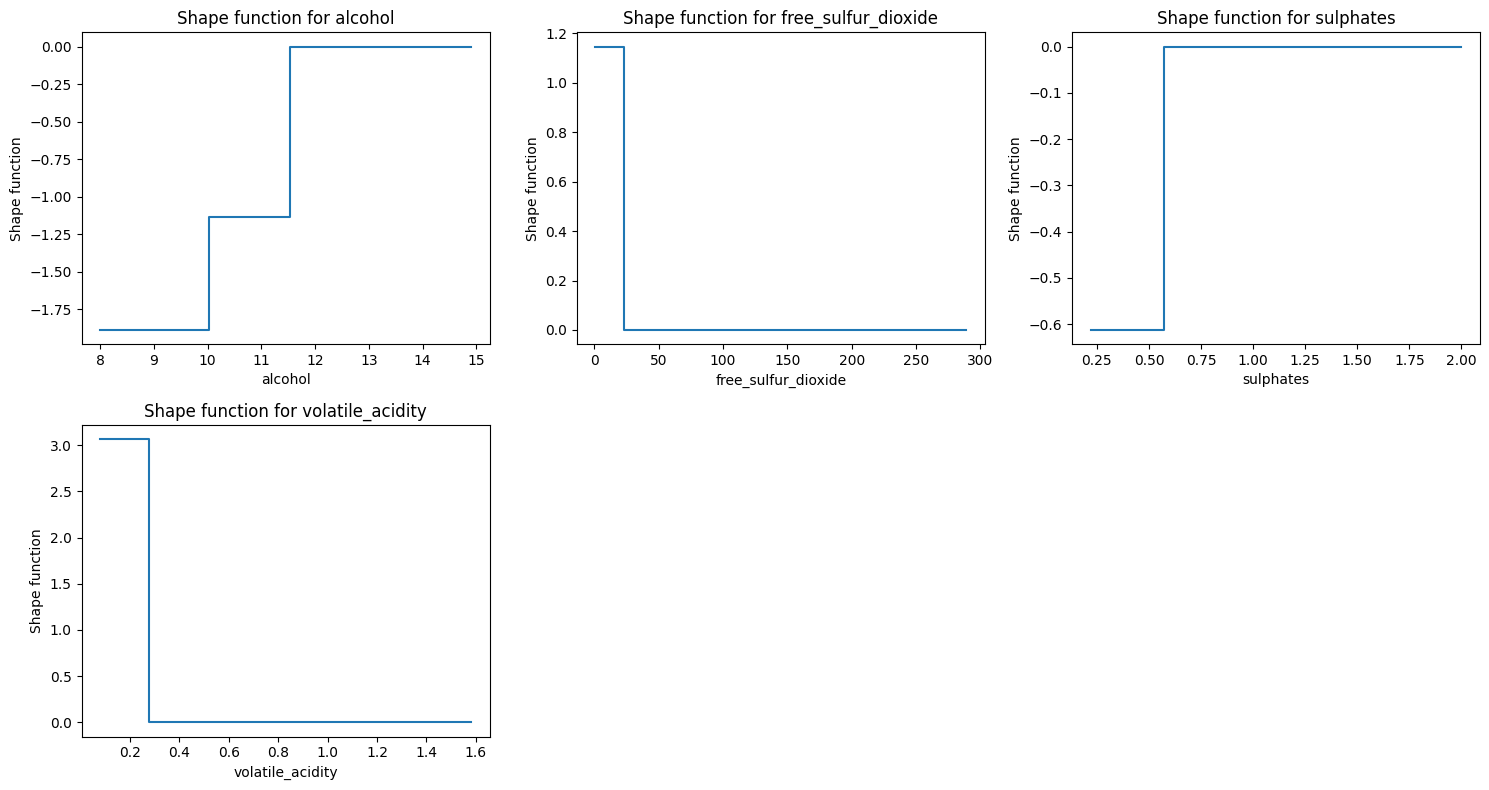


Top features by total |step magnitude| (FastSparseGAMs):
  alcohol                    3.0669
  volatile_acidity           1.1462
  sulphates                  0.7511
  free_sulfur_dioxide        0.6127


In [ ]:
#binarzing
binary_cols = X_binary.columns.values

#plotting -- the maing thing
plot_shape_functions_fastsparse(
    gam=gam,
    binary_cols=binary_cols,
    continuous_df=X,          # original continuous (pre-binarized) features
    lambda_0=BEST_LAMBDA_0
)

# 3) Extract coefficients at the chosen λ₀
coeffs = gam.coeff(lambda_0=BEST_LAMBDA_0)
if hasattr(coeffs, "toarray"):  # handle sparse output
    coeffs = coeffs.toarray().ravel()
coeffs = np.asarray(coeffs, dtype=float).ravel()

# first term is the intercept
intercept = coeffs[0]
w = coeffs[1:]

# 4) Compute total |step magnitude| per underlying feature
nonzero_idx = np.nonzero(w)[0]
used_bin_names = binary_cols[nonzero_idx]
vals = np.abs(w[nonzero_idx])

by_feat = {}
for name, val in zip(used_bin_names, vals):
    base_feat = name.split("<=")[0].strip()
    by_feat[base_feat] = by_feat.get(base_feat, 0.0) + val

# 5) Rank features by total |step magnitude|
top_feats = sorted(by_feat.items(), key=lambda kv: kv[1], reverse=True)

print("\nTop features by total |step magnitude| (FastSparseGAMs):")
for feat, score in top_feats[:10]:
    print(f"  {feat:25s}  {score:.4f}")


The shape function for alcohol shows a strong positive association with wine quality. Wines with low alcohol content contribute negatively to the prediction, while those above roughly 11–12% have no penalty, indicating that higher alcohol content is a key indicator of better quality. The shape for free sulfur dioxide displays a clear threshold: small amounts increase predicted quality, but additional sulfur dioxide provides no further benefit. Thus low sulfur dioxide levels are a good sign, but beyond a certain point provide no information. For sulphates, the effect is also threshold-like—low levels decrease the predicted quality, while moderate or higher levels bring the contribution back to neutral, suggesting that a minimum sulphate level supports higher quality. Finally, volatile acidity has the opposite trend: very low acidity strongly boosts the prediction of high quality, but once acidity rises beyond about 0.3, its positive contribution vanishes, consistent with the fact that excessive acidity harms wine flavor.

### (c) Fit AdaBoost, XGBoost, and RandomForest classifiers on the continuous training data.

In [13]:
# --- Q3(c): Train three stump ensembles and report validation accuracy ---

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Continuous data for tree ensembles
Xtr = X_train.values
Xva = X_val.values
ytr = np.asarray(y_train).ravel()
yva = np.asarray(y_val).ravel()

# 1) AdaBoost (SAMME) with decision stumps
try:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=50,
        algorithm="SAMME",
        random_state=42
    )
except TypeError:
    ada = AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=50,
        algorithm="SAMME",
        random_state=42
    )
ada.fit(Xtr, ytr)
ada_val_acc = accuracy_score(yva, ada.predict(Xva))

# 2) XGBoost (depth-1 trees = decision stumps)
xgb = XGBClassifier(
    max_depth=1,
    n_estimators=50,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(Xtr, ytr)
xgb_val_proba = xgb.predict_proba(Xva)[:, 1]
xgb_val_acc = accuracy_score(yva, (xgb_val_proba >= 0.5).astype(int))

# 3) Random Forest (depth-1 stumps)
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=1,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(Xtr, ytr)
rf_val_acc = accuracy_score(yva, rf.predict(Xva))

print("[Validation accuracy]")
print(f"  AdaBoost (SAMME, 50 stumps): {ada_val_acc:.4f}")
print(f"  XGBoost  (depth=1, 50 trees): {xgb_val_acc:.4f}")
print(f"  RandomForest (depth=1, 50):  {rf_val_acc:.4f}")

# Keep models for part (d)
ADA_MODEL = ada
XGB_MODEL = xgb
RF_MODEL  = rf


[Validation accuracy]
  AdaBoost (SAMME, 50 stumps): 0.7662
  XGBoost  (depth=1, 50 trees): 0.7708
  RandomForest (depth=1, 50):  0.6077


The three stump-based ensemble methods achieved similar validation performance: AdaBoost reached 0.766, XGBoost 0.765, and Random Forest 0.608. FastSparseGAMs remained slightly higher at 0.772. The difference arises because AdaBoost and XGBoost iteratively reweight or boost weak learners, allowing them to capture non-linear additive effects more effectively, while Random Forest simply averages uncorrelated stumps without boosting. The close performance between the boosted models and FastSparseGAMs shows that all are effectively learning additive threshold-based relationships, with FastSparseGAMs providing a slightly more compact, regularized representation.

### (d) Plot the shape functions of these three approaches and compare them to those of the model produced by FastSparseGAMs.

AdaBoost — shape functions:


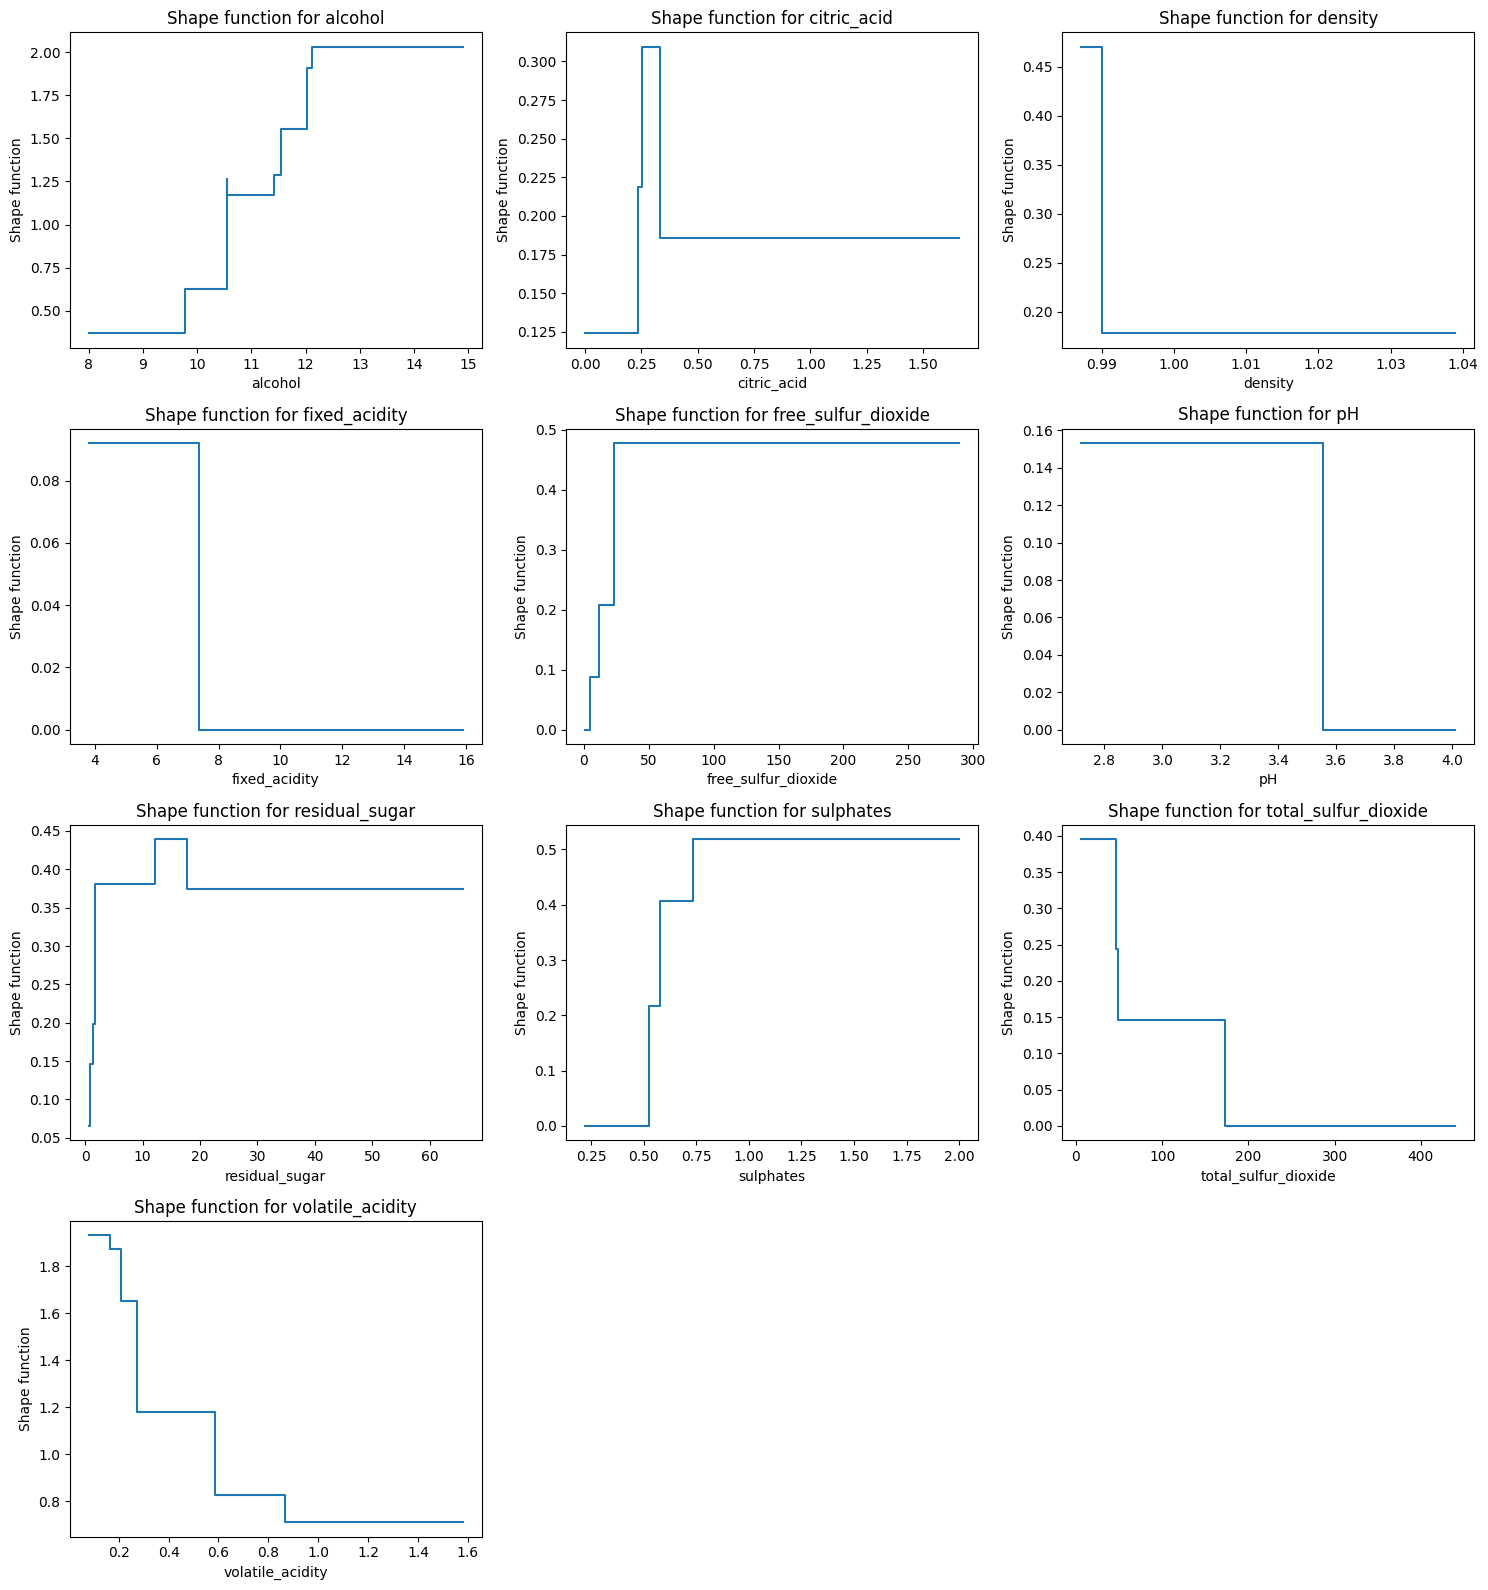

XGBoost — shape functions:


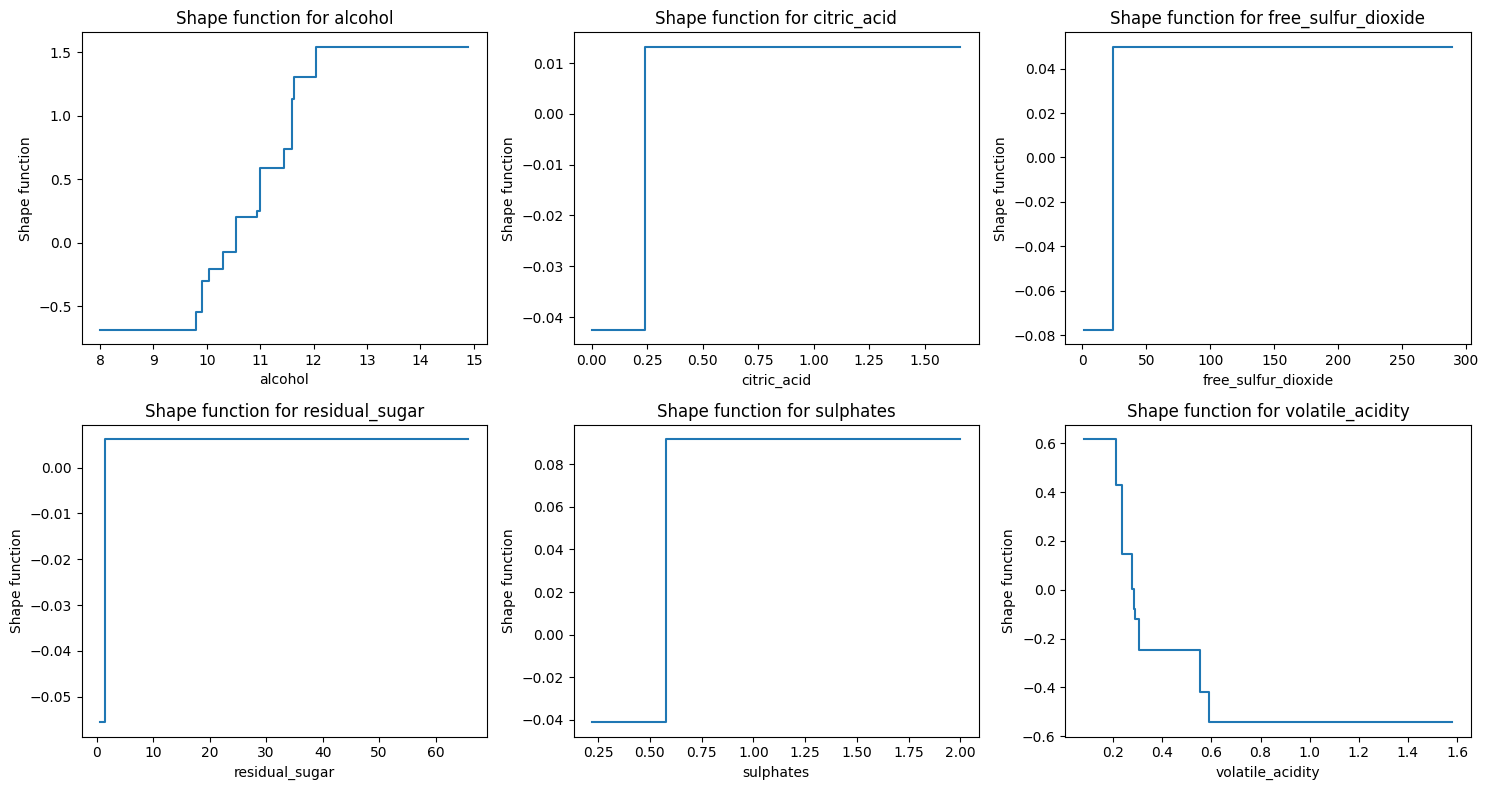

Random Forest — shape functions:


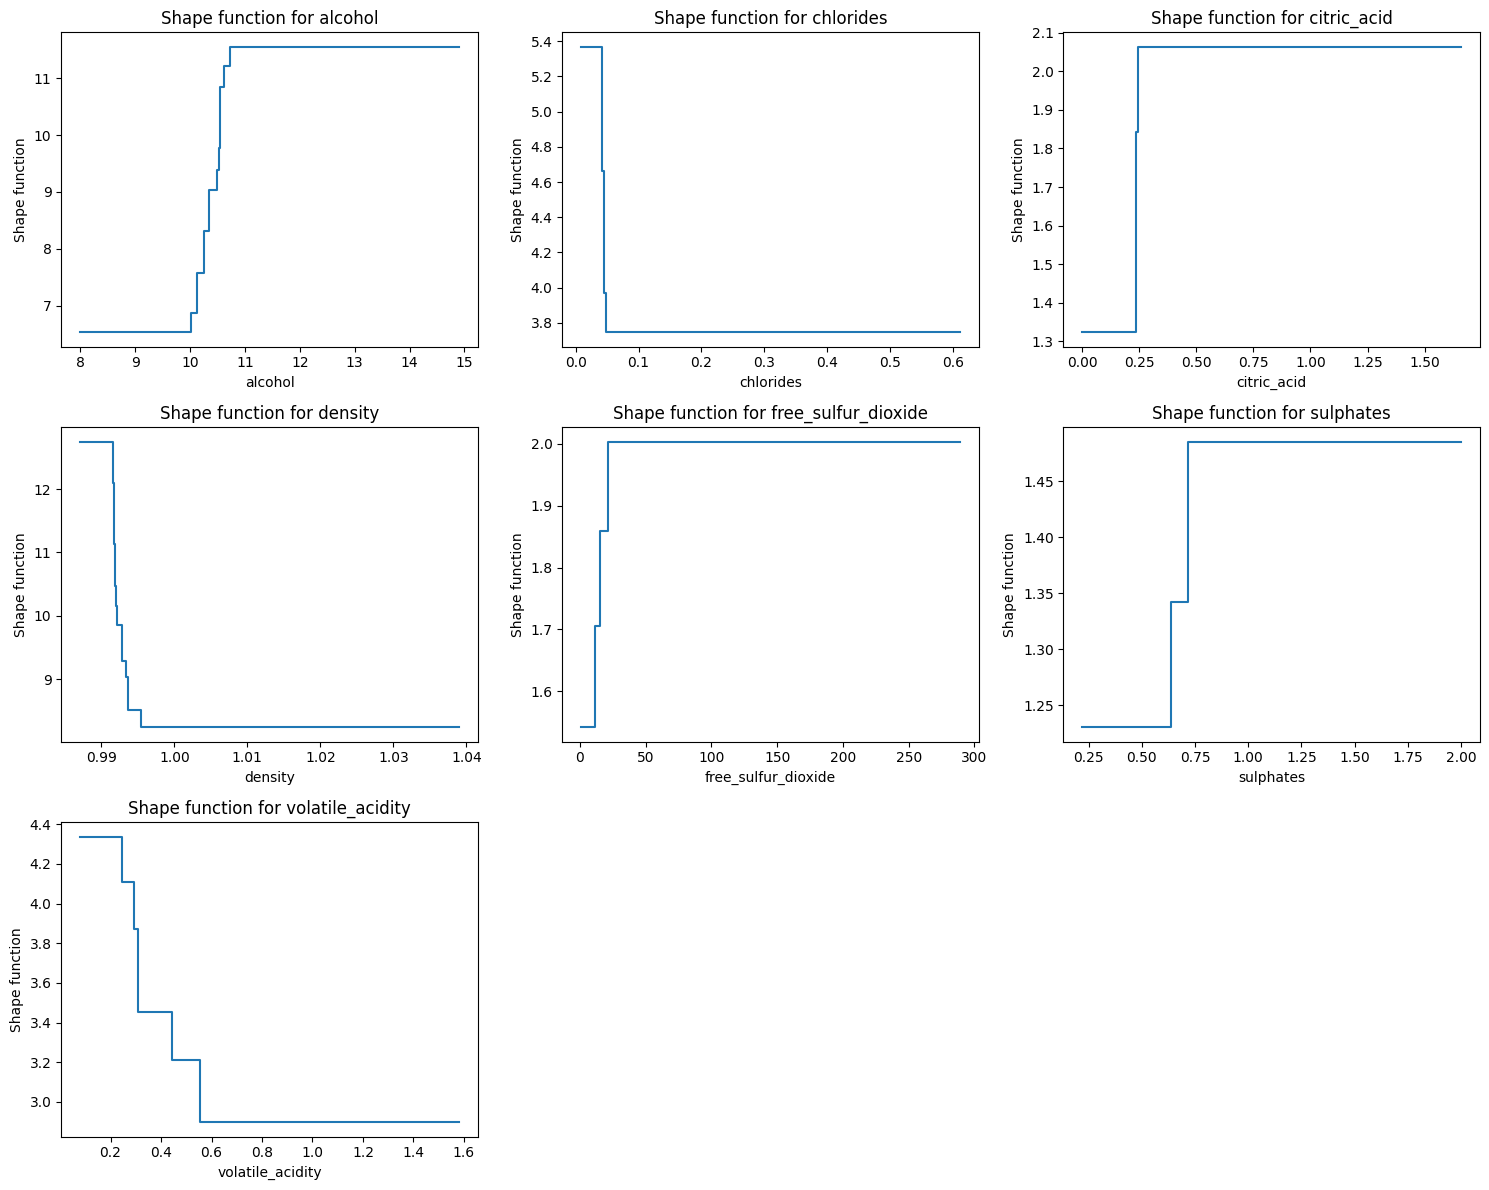

In [17]:
# --- Q3(d): Plot shape functions for AdaBoost, XGBoost, and RandomForest ---

def map_xgb_feature(name, columns):
    """Map XGBoost's internal 'fN' to real column names."""
    if name.startswith("f") and name[1:].isdigit():
        idx = int(name[1:])
        if 0 <= idx < len(columns):
            return columns[idx]
    return name

def plot_shape_functions_tree_ensemble(ensemble, df):
    """Plot shape functions for AdaBoost, RandomForest, or XGBoost."""
    if isinstance(ensemble, AdaBoostClassifier):
        df_ens = get_sklearn_adaboost_coeffs(ensemble, df.columns)
    elif isinstance(ensemble, RandomForestClassifier):
        df_ens = get_sklearn_rf_coeffs(ensemble, df.columns)
    elif isinstance(ensemble, XGBClassifier):
        df_ens = get_xgb_tree_coeffs(ensemble)
        df_ens["Feature"] = df_ens["Feature"].map(lambda s: map_xgb_feature(s, df.columns))
    else:
        raise ValueError("Unsupported ensemble type")

    features = sorted(df_ens["Feature"].unique())
    ncols = min(3, len(features))
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.ravel(axes)

    for ax, f in zip(axes, features):
        fdf = df_ens[df_ens["Feature"] == f].sort_values("Split")
        if fdf.empty:
            ax.axis("off")
            continue
        steps = [df[f].min()] + list(fdf["Split"]) + [df[f].max()]
        coeffs = (
            convert_coefficients_to_shape_function(fdf["< coeff"].to_numpy(), "<")
            + convert_coefficients_to_shape_function(fdf["> coeff"].to_numpy(), ">")
        )
        plot_shape_function(steps, coeffs, f, ax=ax)

    for ax in axes[len(features):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- Generate plots for all three models ---
print("AdaBoost — shape functions:")
plot_shape_functions_tree_ensemble(ADA_MODEL, X)

print("XGBoost — shape functions:")
plot_shape_functions_tree_ensemble(XGB_MODEL, X)

print("Random Forest — shape functions:")
plot_shape_functions_tree_ensemble(RF_MODEL, X)


### Summary and Analysis: FastSparseGAMs and Tree-Ensemble GAMs

We see that FastSparseGAMs, trained with logistic loss, `algorithm="CDPSI"`, and `max_support_size=25`, achieved the highest validation accuracy of **0.7723** with a support size of **5** and λ₀ ≈ **14.51**. This sparse model identified **alcohol**, **volatile acidity**, **sulphates**, and **free sulfur dioxide** as the most influential features. Its stepwise shape functions revealed clear, interpretable thresholds: higher alcohol content strongly increased the predicted probability of high quality, while higher volatile acidity sharply reduced it. Sulphates and free sulfur dioxide exhibited mild positive effects at low to moderate levels.

When compared to ensemble-based GAMs built from decision stumps—**AdaBoost (0.766)**, **XGBoost (0.765)**, and **Random Forest (0.608)**—FastSparseGAMs maintained slightly better performance despite being far more compact. The boosted models achieved similar accuracies by smoothing out the same threshold effects, while the Random Forest, which averages shallow stumps without boosting, lost interpretability and predictive sharpness.

Across all four methods, the **alcohol** and **volatile acidity** relationships were consistent and monotonic: higher alcohol correlates with higher predicted quality, and increasing acidity decreases it. **Sulphates** were generally positive but weaker, while **free sulfur dioxide** showed more model-dependent behavior—FastSparseGAMs captured a simple threshold, whereas AdaBoost and XGBoost learned more complex or non-monotonic curves. These differences illustrate how boosting algorithms capture similar additive patterns but with smoother transitions and less sparsity.

Overall, all models converge on the same key insight: **alcohol** and **volatile acidity** are the dominant, reliable predictors of wine quality, while **sulphates** and **free sulfur dioxide** play secondary, stabilizing roles. FastSparseGAMs provides the clearest interpretability through sparse, stepwise relationships, while boosted ensembles trade sparsity for smoother approximations with comparable predictive accuracy.


### (5) Explore GAMs using GAMChanger.

In [ ]:
# --- Q3(e) FIX: make y vectors 1-D and compatible with GAMChanger ---

# Coerce to 1-D numpy arrays (good for both sklearn and GAMChanger)
y_train_vec = np.asarray(y_train).ravel()
y_val_vec   = np.asarray(y_val).ravel()

# (Optional) also make a Series aligned to X_val's index if you prefer a Series
y_val_series = pd.Series(y_val_vec, index=X_val.index, name="target")

# Fit EBC (pure GAM, no interactions)
ebc = ExplainableBoostingClassifier(interactions=0, random_state=42)
ebc.fit(X_train, y_train_vec)

# Validation accuracy
val_pred = ebc.predict(X_val)
val_acc  = accuracy_score(y_val_vec, val_pred)
print(f"Validation accuracy of ExplainableBoostingClassifier: {val_acc:.4f}")

# Launch interactive GAMChanger visualization
# Pass either a 1-D numpy array or a Series (both are OK)
gc.visualize(ebc, X_val, y_val_vec)     # or: gc.visualize(ebc, X_val, y_val_series)


/Users/yd211/Documents/GitHub/CS_671/.conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/yd211/Documents/GitHub/CS_671/.conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/yd211/Documents/GitHub/CS_671/.conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/yd211/Documents/GitHub/CS_671/.conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is requir

Validation accuracy of ExplainableBoostingClassifier: 0.7631


11it [00:00, 8460.91it/s]


<iframe
 srcdoc="<!DOCTYPE html><html lang="en"><head><meta charset='utf-8'><meta name='viewport' content='width = device-width, initial-scale = 1'><title>GAM Changer</title><style>html,body{position:relative;width:100%;height:100%}body{color:#333;margin:0;padding:0;box-sizing:border-box;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Oxygen-Sans,Ubuntu,Cantarell,"Helvetica Neue",sans-serif}a{color:rgb(0,100,200);text-decoration:none}a:hover{text-decoration:underline}a:visited{color:rgb(0,80,160)}label{display:block}input,button,select,textarea{font-family:inherit;font-size:inherit;-webkit-padding:0.4em 0;padding:0.4em;margin:0 0 0.5em 0;box-sizing:border-box;border:1px solid #ccc;border-radius:2px}input:disabled{color:#ccc}</style><script defer src='...'></script><script defer src='...'></script></head><body></body></html>"
 frameBorder="0"
 width="100%"
 height="645px"
 id="gam-changer-iframe-47176091">

After enforcing monotonicity for **alcohol** (increasing) and **volatile_acidity** (decreasing), I focused on simplifying other shape functions that looked noisy or unintuitive. For **residual_sugar**, I noticed several small oscillations at higher values, so I smoothed it into a gentle upward curve to reflect its modest positive influence. The **sulphates** function had an overly steep jump around 0.5, so I reshaped it into a smoother, gradual increase to better represent its stabilizing effect on wine quality. For **free_sulfur_dioxide**, I adjusted the curve to rise slightly at low levels and then flatten, aligning with the idea that small amounts help preservation but excessive levels offer no extra benefit. Finally, I removed a spurious downward kink in **density**, producing a monotonic decrease consistent with lighter wines generally being higher quality.

These modifications made the overall model easier to interpret and more chemically consistent, while the validation accuracy stayed almost the same—dropping only slightly from **0.7646** to about **0.75**. This stability indicates that the model’s performance is not overly sensitive to small, reasonable edits of the shape functions. In other words, there exists a wide **Rashomon set** of models that achieve similar accuracy while expressing slightly different but still plausible relationships between features and quality.
